<div style='color: #216969;
           background-color: #EAF6F6;
           font-size: 200%;
           border-radius:15px;
           text-align:center;
           font-weight:600;
           border-style: solid;
           border-color: dark green;
           font-family: "Cambria";'>
Naive Bayes ....
<a class="anchor" id="1"></a> 

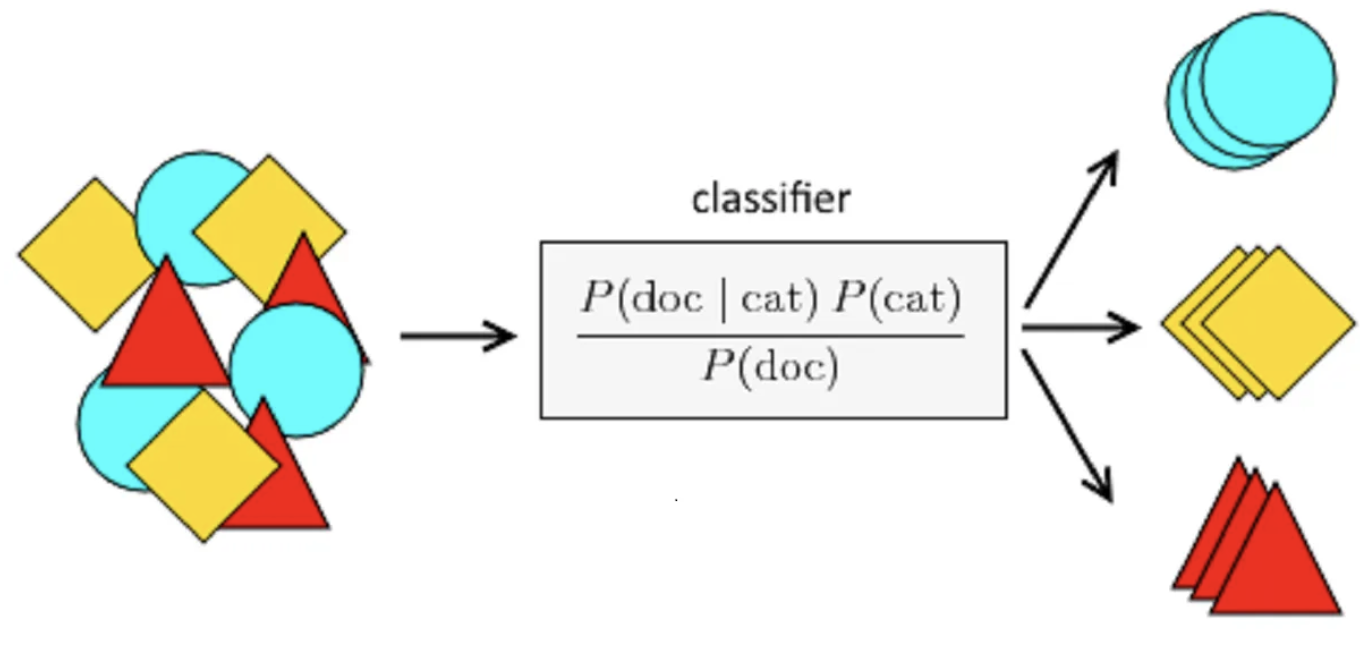

In [2]:
import sklearn
print(sklearn.__version__)  # Should be 1.4.x or higher

1.6.1


In [1]:


import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt # for data visualization purposes
import seaborn as sns # for statistical data visualization
%matplotlib inline



In [2]:
import warnings

warnings.filterwarnings('ignore')

In [3]:
# dataset loading 
df = pd.read_csv("../data/adult.csv", header=None) #, sep=',\s')

![](../../imgs/featureEngin.png)

In [4]:
df.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [5]:
# view dimensions of dataset

df.shape

(32561, 15)

In [6]:
# preview the dataset

df.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [7]:
# rename columns 
col_names = ['age', 'workclass', 'fnlwgt', 'education', 'education_num', 'marital_status', 'occupation', 'relationship',
             'race', 'sex', 'capital_gain', 'capital_loss', 'hours_per_week', 'native_country', 'income']

df.columns = col_names

df.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'education_num',
       'marital_status', 'occupation', 'relationship', 'race', 'sex',
       'capital_gain', 'capital_loss', 'hours_per_week', 'native_country',
       'income'],
      dtype='object')

In [8]:
df.head() #  display 5 first rows of our dataset 

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [9]:
# view summary of dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education_num   32561 non-null  int64 
 5   marital_status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital_gain    32561 non-null  int64 
 11  capital_loss    32561 non-null  int64 
 12  hours_per_week  32561 non-null  int64 
 13  native_country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [10]:
cat_features= df.select_dtypes("object").columns
print(f"  categorical features \n :{cat_features}")
print(f" there are : \n {cat_features.shape[0]}  categorical features ")

  categorical features 
 :Index(['workclass', 'education', 'marital_status', 'occupation',
       'relationship', 'race', 'sex', 'native_country', 'income'],
      dtype='object')
 there are : 
 9  categorical features 


In [11]:
# view the categorical variables

df[cat_features].head()

,workclass,education,marital_status,occupation,relationship,race,sex,native_country,income
0,State-gov,Bachelors,Never-married,Adm-clerical,Not-in-family,White,Male,United-States,<=50K
1,Self-emp-not-inc,Bachelors,Married-civ-spouse,Exec-managerial,Husband,White,Male,United-States,<=50K
2,Private,HS-grad,Divorced,Handlers-cleaners,Not-in-family,White,Male,United-States,<=50K
3,Private,11th,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,United-States,<=50K
4,Private,Bachelors,Married-civ-spouse,Prof-specialty,Wife,Black,Female,Cuba,<=50K


In [12]:
# check missing values in categorical variables

df[cat_features].isnull().sum()

workclass         0
education         0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
native_country    0
income            0
dtype: int64

In [13]:
# view frequency counts of values in categorical variables

for col  in cat_features:
    print(f" Feature : {col:->30} : {df[col].value_counts()}")

 Feature : ---------------------workclass : workclass
Private             22696
Self-emp-not-inc     2541
Local-gov            2093
?                    1836
State-gov            1298
Self-emp-inc         1116
Federal-gov           960
Without-pay            14
Never-worked            7
Name: count, dtype: int64
 Feature : ---------------------education : education
HS-grad         10501
Some-college     7291
Bachelors        5355
Masters          1723
Assoc-voc        1382
11th             1175
Assoc-acdm       1067
10th              933
7th-8th           646
Prof-school       576
9th               514
12th              433
Doctorate         413
5th-6th           333
1st-4th           168
Preschool          51
Name: count, dtype: int64
 Feature : ----------------marital_status : marital_status
Married-civ-spouse       14976
Never-married            10683
Divorced                  4443
Separated                 1025
Widowed                    993
Married-spouse-absent      418
Married-A

In [14]:
# view frequency distribution of categorical variables

# for var in categorical:
#     print(df[var].value_counts()/np.float(len(df)))

In [15]:
# check labels in workclass variable

df.workclass.unique()

array([' State-gov', ' Self-emp-not-inc', ' Private', ' Federal-gov',
       ' Local-gov', ' ?', ' Self-emp-inc', ' Without-pay',
       ' Never-worked'], dtype=object)

In [16]:
# check frequency distribution of values in workclass variable

df.workclass.value_counts()

workclass
Private             22696
Self-emp-not-inc     2541
Local-gov            2093
?                    1836
State-gov            1298
Self-emp-inc         1116
Federal-gov           960
Without-pay            14
Never-worked            7
Name: count, dtype: int64

In [17]:
# again check the frequency distribution of values in workclass variable

df.workclass.value_counts()

workclass
Private             22696
Self-emp-not-inc     2541
Local-gov            2093
?                    1836
State-gov            1298
Self-emp-inc         1116
Federal-gov           960
Without-pay            14
Never-worked            7
Name: count, dtype: int64

In [18]:
# check labels in occupation variable

df.occupation.unique()


array([' Adm-clerical', ' Exec-managerial', ' Handlers-cleaners',
       ' Prof-specialty', ' Other-service', ' Sales', ' Craft-repair',
       ' Transport-moving', ' Farming-fishing', ' Machine-op-inspct',
       ' Tech-support', ' ?', ' Protective-serv', ' Armed-Forces',
       ' Priv-house-serv'], dtype=object)

In [19]:
# check frequency distribution of values in occupation variable

df.occupation.value_counts()

occupation
Prof-specialty       4140
Craft-repair         4099
Exec-managerial      4066
Adm-clerical         3770
Sales                3650
Other-service        3295
Machine-op-inspct    2002
?                    1843
Transport-moving     1597
Handlers-cleaners    1370
Farming-fishing       994
Tech-support          928
Protective-serv       649
Priv-house-serv       149
Armed-Forces            9
Name: count, dtype: int64

In [20]:
df.isin(['?']).any(axis=0).sum()

np.int64(0)

In [21]:
cat_features

Index(['workclass', 'education', 'marital_status', 'occupation',
       'relationship', 'race', 'sex', 'native_country', 'income'],
      dtype='object')

In [22]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(missing_values="?", strategy='most_frequent')
df[cat_features]= imputer.fit_transform(df[cat_features])

In [23]:
df.isin(['?']).any(axis=0)

age               False
workclass         False
fnlwgt            False
education         False
education_num     False
marital_status    False
occupation        False
relationship      False
race              False
sex               False
capital_gain      False
capital_loss      False
hours_per_week    False
native_country    False
income            False
dtype: bool

In [24]:
# again check the frequency distribution of values in occupation variable

df.occupation.value_counts()

occupation
Prof-specialty       4140
Craft-repair         4099
Exec-managerial      4066
Adm-clerical         3770
Sales                3650
Other-service        3295
Machine-op-inspct    2002
?                    1843
Transport-moving     1597
Handlers-cleaners    1370
Farming-fishing       994
Tech-support          928
Protective-serv       649
Priv-house-serv       149
Armed-Forces            9
Name: count, dtype: int64

In [25]:
# check labels in native_country variable

df.native_country.unique()


array([' United-States', ' Cuba', ' Jamaica', ' India', ' ?', ' Mexico',
       ' South', ' Puerto-Rico', ' Honduras', ' England', ' Canada',
       ' Germany', ' Iran', ' Philippines', ' Italy', ' Poland',
       ' Columbia', ' Cambodia', ' Thailand', ' Ecuador', ' Laos',
       ' Taiwan', ' Haiti', ' Portugal', ' Dominican-Republic',
       ' El-Salvador', ' France', ' Guatemala', ' China', ' Japan',
       ' Yugoslavia', ' Peru', ' Outlying-US(Guam-USVI-etc)', ' Scotland',
       ' Trinadad&Tobago', ' Greece', ' Nicaragua', ' Vietnam', ' Hong',
       ' Ireland', ' Hungary', ' Holand-Netherlands'], dtype=object)

In [26]:
# check frequency distribution of values in native_country variable

df.native_country.value_counts()


native_country
United-States                 29170
Mexico                          643
?                               583
Philippines                     198
Germany                         137
Canada                          121
Puerto-Rico                     114
El-Salvador                     106
India                           100
Cuba                             95
England                          90
Jamaica                          81
South                            80
China                            75
Italy                            73
Dominican-Republic               70
Vietnam                          67
Guatemala                        64
Japan                            62
Poland                           60
Columbia                         59
Taiwan                           51
Haiti                            44
Iran                             43
Portugal                         37
Nicaragua                        34
Peru                             31
France       

We can see that there are 583 values encoded as `?` in `native_country` variable. I will replace these `?` with `NaN`.


In [27]:
# again check the frequency distribution of values in native_country variable

df.native_country.value_counts()

native_country
United-States                 29170
Mexico                          643
?                               583
Philippines                     198
Germany                         137
Canada                          121
Puerto-Rico                     114
El-Salvador                     106
India                           100
Cuba                             95
England                          90
Jamaica                          81
South                            80
China                            75
Italy                            73
Dominican-Republic               70
Vietnam                          67
Guatemala                        64
Japan                            62
Poland                           60
Columbia                         59
Taiwan                           51
Haiti                            44
Iran                             43
Portugal                         37
Nicaragua                        34
Peru                             31
France       

In [28]:
df[cat_features].isnull().sum()

workclass         0
education         0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
native_country    0
income            0
dtype: int64

In [29]:
for col in df.select_dtypes("object").columns:
    print(f" {col:-<30} {df[col].nunique()}")

 workclass--------------------- 9
 education--------------------- 16
 marital_status---------------- 7
 occupation-------------------- 15
 relationship------------------ 6
 race-------------------------- 5
 sex--------------------------- 2
 native_country---------------- 42
 income------------------------ 2


In [30]:
# find numerical variables

num_features = df.select_dtypes("number").columns

print(f'There are : {len(num_features)} numerical variables\n')

print(f'The numerical variables are :', num_features)

There are : 6 numerical variables

The numerical variables are : Index(['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss',
       'hours_per_week'],
      dtype='object')


In [31]:
# view the numerical variables

df[num_features].head()

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
0,39,77516,13,2174,0,40
1,50,83311,13,0,0,13
2,38,215646,9,0,0,40
3,53,234721,7,0,0,40
4,28,338409,13,0,0,40


In [32]:
# check missing values in numerical variables

df[num_features].isnull().sum()

age               0
fnlwgt            0
education_num     0
capital_gain      0
capital_loss      0
hours_per_week    0
dtype: int64

In [33]:
# check missing values in cat variables

df[cat_features].isnull().sum()

workclass         0
education         0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
native_country    0
income            0
dtype: int64

In [34]:
df.income.value_counts()

income
<=50K    24720
>50K      7841
Name: count, dtype: int64

In [35]:
df["income"]= ((df.income==">50K")+0)

In [36]:
X = df.drop(['income'], axis=1)

y = df['income']

In [37]:
# split X and y into training and testing sets

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, stratify=y,  random_state = 0)


In [38]:
# check the shape of X_train and X_test

X_train.shape, X_test.shape

((22792, 14), (9769, 14))

In [39]:
# encode remaining variables with one-hot encoding
cat_features= X_train.select_dtypes("object").columns
num_features= X_train.select_dtypes("number").columns

In [40]:
import sklearn
print(sklearn.__version__)  # Should be 1.4.x or higher

1.6.1


In [41]:

#encoder = ce.OneHotEncoder(cols=['workclass', 'education', 'marital_status', 'occupation', 'relationship',
#                                 'race', 'sex', 'native_country'])
# Initialize the OneHotEncoder
from sklearn.preprocessing import StandardScaler , OneHotEncoder, RobustScaler
from sklearn.compose import make_column_transformer , make_column_selector  as selector
# from sklearn.compose import

from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline



num_pipeline= make_pipeline(
    SimpleImputer(strategy="mean" ),
    RobustScaler()
)

cat_pipeline= make_pipeline(
    SimpleImputer(strategy="most_frequent" ),
    OneHotEncoder(handle_unknown="ignore"  , sparse_output=False))



preprocess= make_column_transformer(
     ( num_pipeline,  selector(dtype_include="number") ),
     (cat_pipeline, selector(dtype_include="object")) ,
     remainder="passthrough"
     )


In [42]:
X_train.shape

(22792, 14)

Similarly, I will take a look at the `X_test` set.

In [43]:
X_test.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country
31572,36,Private,418702,Assoc-voc,11,Divorced,Adm-clerical,Unmarried,White,Female,0,0,40,United-States
14428,27,Private,204515,Bachelors,13,Never-married,Tech-support,Not-in-family,White,Female,0,0,36,United-States
22297,30,Private,203258,HS-grad,9,Never-married,Other-service,Not-in-family,White,Female,0,0,35,United-States
9965,29,Private,24153,Some-college,10,Married-civ-spouse,Other-service,Wife,Amer-Indian-Eskimo,Female,0,0,40,United-States
15809,58,Self-emp-not-inc,143731,HS-grad,9,Married-civ-spouse,Sales,Husband,White,Male,0,0,72,United-States


In [44]:
# import GaussianBN 
from sklearn.naive_bayes import GaussianNB

final_pipeline_gnb = make_pipeline(
    preprocess,
    GaussianNB() # Added with default parameters (var_smoothing=1e-9)
)


In [45]:
final_pipeline_gnb

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('pipeline-1',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer()),
                                                                  ('robustscaler',
                                                                   RobustScaler())]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x77fff0e43890>),
                                                 ('pipeline-2',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x77fff0e43860>)])),
                ('gaussiannb', GaussianNB())])

In [46]:
# Fit the entire pipeline on training data
final_pipeline_gnb.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('pipeline-1',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer()),
                                                                  ('robustscaler',
                                                                   RobustScaler())]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x77fff0e43890>),
                                                 ('pipeline-2',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x77fff0e43860>)])),
                ('gaussiannb', GaussianNB())])

In [47]:
# Make predictions on test data
y_pred = final_pipeline_gnb.predict(X_test)

In [48]:
y_pred

array([0, 0, 0, ..., 0, 0, 0], shape=(9769,))

In [49]:
# Evaluate predictions

from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 1.0000


# PipeLIne PCA & GaussianNB

In [50]:
preprocess.fit_transform(X_train).shape

(22792, 107)

In [51]:
from sklearn.naive_bayes import GaussianNB
from sklearn.decomposition import PCA
pipe_NB= make_pipeline(
    preprocess,
    PCA( ),
    GaussianNB()
)

In [52]:
from sklearn import set_config
set_config(display='diagram', )

In [53]:
# Define a range of var_smoothing values
from sklearn.metrics import log_loss
var_smoothing_values = np.logspace(-10, -6, num=20)  # From 1e-10 to 1e-6

# Lists to store losses
train_losses = []
test_losses = []

# Compute log loss for each var_smoothing value
for var_smoothing in var_smoothing_values:
    # Update the pipeline with the new var_smoothing value
    pipe_NB.set_params(gaussiannb__var_smoothing=var_smoothing)

    # Fit the pipeline
    pipe_NB.fit(X_train, y_train)

    # Get probability predictions
    y_train_pred_proba = pipe_NB.predict_proba(X_train)
    y_test_pred_proba = pipe_NB.predict_proba(X_test)

    # Compute log loss
    train_loss = log_loss(y_train, y_train_pred_proba)
    test_loss = log_loss(y_test, y_test_pred_proba)

    train_losses.append(train_loss)
    test_losses.append(test_loss)

ValueError: y_true contains only one label (0). Please provide the true labels explicitly through the labels argument.

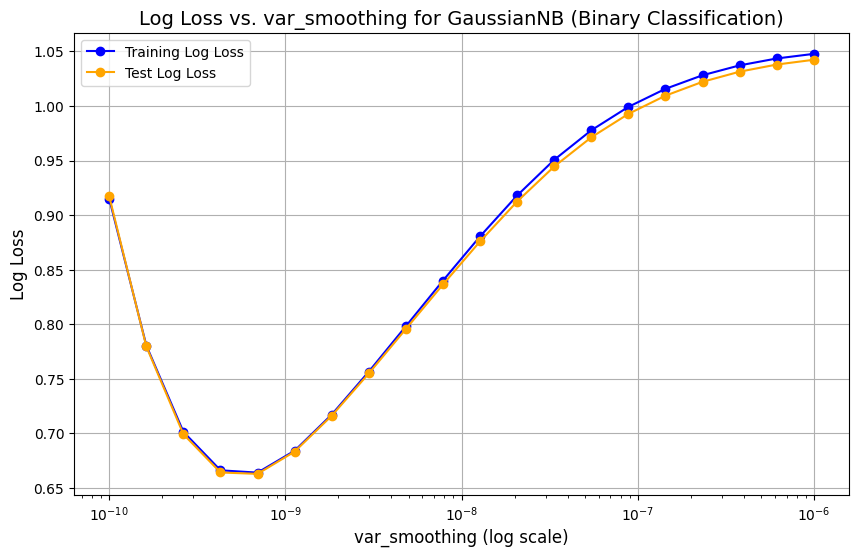

In [ ]:
# Plot the loss curves
plt.figure(figsize=(10, 6))
plt.plot(var_smoothing_values, train_losses, label='Training Log Loss', color='blue', marker='o')
plt.plot(var_smoothing_values, test_losses, label='Test Log Loss', color='orange', marker='o')
plt.xscale('log')  # Use logarithmic scale for better visualization
plt.title('Log Loss vs. var_smoothing for GaussianNB (Binary Classification)', fontsize=14)
plt.xlabel('var_smoothing (log scale)', fontsize=12)
plt.ylabel('Log Loss', fontsize=12)
plt.legend()
plt.grid(True)
plt.show()

In [54]:
# Find the best var_smoothing based on test loss
best_idx = np.argmin(test_losses)  # Index of the minimum test loss
best_var_smoothing = var_smoothing_values[best_idx]
best_test_loss = test_losses[best_idx]
best_train_loss = train_losses[best_idx]

print(f"Best var_smoothing: {best_var_smoothing:.1e}")
print(f"Best Test Log Loss: {best_test_loss:.4f}")
print(f"Best Train Log Loss: {best_train_loss:.4f}")

ValueError: attempt to get argmin of an empty sequence

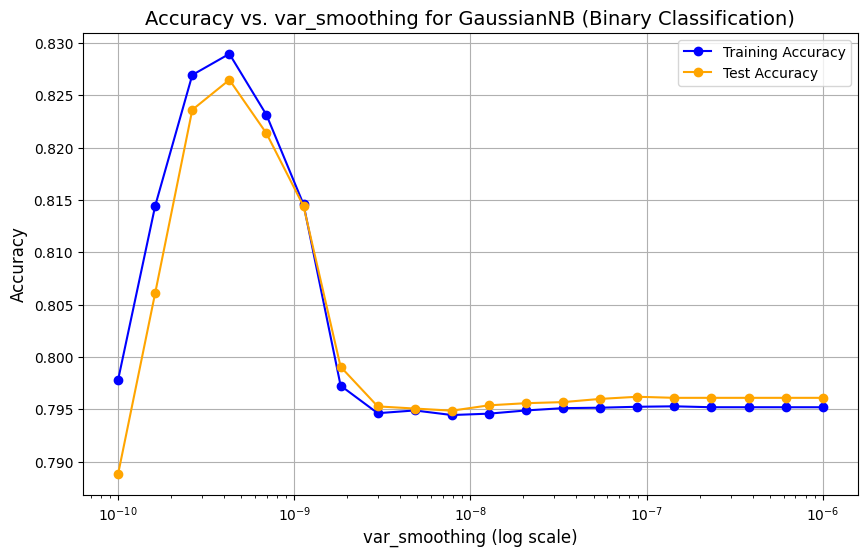

In [ ]:
from sklearn.metrics import accuracy_score

train_accuracies = []
test_accuracies = []

for var_smoothing in var_smoothing_values:
    pipe_NB.set_params(gaussiannb__var_smoothing=var_smoothing)
    pipe_NB.fit(X_train, y_train)
    train_accuracies.append(accuracy_score(y_train, pipe_NB.predict(X_train)))
    test_accuracies.append(accuracy_score(y_test, pipe_NB.predict(X_test)))

plt.figure(figsize=(10, 6))
plt.plot(var_smoothing_values, train_accuracies, label='Training Accuracy', color='blue', marker='o')
plt.plot(var_smoothing_values, test_accuracies, label='Test Accuracy', color='orange', marker='o')
plt.xscale('log')
plt.title('Accuracy vs. var_smoothing for GaussianNB (Binary Classification)', fontsize=14)
plt.xlabel('var_smoothing (log scale)', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend()
plt.grid(True)
plt.show()

In [55]:
# display best var_smoothing value giving highest accuracy 


# GridSearch

In [56]:
pipe_NB.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('pipeline-1',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer()),
                                                                  ('robustscaler',
                                                                   RobustScaler())]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x77fff0e43890>),
                                                 ('pipeline-2',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x77fff0e43860>)])),
                ('pca', PCA()),
                ('gaussiannb', GaussianNB(var_smoothing=np.float64(1e-10)))])

In [57]:
list(pipe_NB.get_params().keys())

['memory',
 'steps',
 'transform_input',
 'verbose',
 'columntransformer',
 'pca',
 'gaussiannb',
 'columntransformer__force_int_remainder_cols',
 'columntransformer__n_jobs',
 'columntransformer__remainder',
 'columntransformer__sparse_threshold',
 'columntransformer__transformer_weights',
 'columntransformer__transformers',
 'columntransformer__verbose',
 'columntransformer__verbose_feature_names_out',
 'columntransformer__pipeline-1',
 'columntransformer__pipeline-2',
 'columntransformer__pipeline-1__memory',
 'columntransformer__pipeline-1__steps',
 'columntransformer__pipeline-1__transform_input',
 'columntransformer__pipeline-1__verbose',
 'columntransformer__pipeline-1__simpleimputer',
 'columntransformer__pipeline-1__robustscaler',
 'columntransformer__pipeline-1__simpleimputer__add_indicator',
 'columntransformer__pipeline-1__simpleimputer__copy',
 'columntransformer__pipeline-1__simpleimputer__fill_value',
 'columntransformer__pipeline-1__simpleimputer__keep_empty_features',


In [58]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid
param_grid = {
    'gaussiannb__priors': [None, [0.3, 0.7], [0.5, 0.5]],  # None = empirical priors, or custom priors
    'gaussiannb__var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6] ,  # Different smoothing values
    'pca__n_components':[40, 60, 80] #
 }

In [59]:
# Initialize GridSearchCV
grid_search = GridSearchCV(
    pipe_NB,
    param_grid=param_grid,
    cv=3,  # 3-fold cross-validation
    scoring='accuracy',
    n_jobs=-1  # Use all available CPU cores
)


In [62]:
# Fit GridSearchCV on the training data
grid_search_result= grid_search.fit(X_train, y_train)

In [68]:
# display all grid_search_result params 
grid_search_result.best_estimator_.get_params()
# display best params

{'memory': None,
 'steps': [('columntransformer',
   ColumnTransformer(remainder='passthrough',
                     transformers=[('pipeline-1',
                                    Pipeline(steps=[('simpleimputer',
                                                     SimpleImputer()),
                                                    ('robustscaler',
                                                     RobustScaler())]),
                                    <sklearn.compose._column_transformer.make_column_selector object at 0x77ffee9a8e60>),
                                   ('pipeline-2',
                                    Pipeline(steps=[('simpleimputer',
                                                     SimpleImputer(strategy='most_frequent')),
                                                    ('onehotencoder',
                                                     OneHotEncoder(handle_unknown='ignore',
                                                                   sparse

In [65]:





# Print the best parameters and score
print("Best Parameters:", grid_search_result.best_params_)
print("Best Cross-Validation Score:", grid_search_result.best_score_)


Best Parameters: {'gaussiannb__priors': None, 'gaussiannb__var_smoothing': 1e-09, 'pca__n_components': 40}
Best Cross-Validation Score: 1.0


In [82]:
common_params = {
    "X": X_train,
    "y": y_train,
    "train_sizes": np.linspace(0.1, 1.0, 10),
    "cv": 5,
    "score_type": "both",
    "n_jobs": -1,
    "line_kw": {"marker": "o"},
    "std_display_style": "fill_between",
    "score_name": "Accuracy"
}

In [ ]:
from sklearn.model_selection import LearningCurveDisplay
fig, ax = plt.subplots(figsize=(8, 6))
LearningCurveDisplay.from_estimator(grid_search_result, **common_params, ax=ax)
ax.set_title("Learning Curve for RandomForestClassifier")
ax.set_xlabel("Training Examples")
ax.set_ylabel("Accuracy")
plt.grid(True)
plt.show()

/home/codespace/.local/lib/python3.12/site-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
72 fits failed out of a total of 108.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
72 fits failed with the following error:
Traceback (most recent call last):
  File "/home/codespace/.local/lib/python3.12/site-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/home/codespace/.local/lib/python3.12/site-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/codespace/.local/lib/python3.12/site-packages/sklearn/pipeline.py", line 662,

In [72]:
# Extract var_smoothing values
var_smoothing_values = grid_search.cv_results_['param_gaussiannb__var_smoothing'].data

# Lists to store metrics
train_accuracies = []
val_accuracies = []
train_losses = []
val_losses = []

# Compute metrics for each var_smoothing value
for var_smoothing in var_smoothing_values:
    # Update the pipeline with the current var_smoothing value
    pipe_NB.set_params(gaussiannb__var_smoothing=var_smoothing)

    # Fit the pipeline on the full training data
    pipe_NB.fit(X_train, y_train)

    # Compute training metrics
    y_train_pred = pipe_NB.predict(X_train)
    y_train_pred_proba = pipe_NB.predict_proba(X_train)
    train_accuracy = accuracy_score(y_train, y_train_pred)
    train_loss = log_loss(y_train, y_train_pred_proba)
    train_accuracies.append(train_accuracy)
    train_losses.append(train_loss)

# Extract validation metrics from cv_results_
val_accuracies = grid_search.cv_results_['mean_test_score']

# Compute validation log loss by refitting on training folds
val_losses = []
for var_smoothing in var_smoothing_values:
    pipe_NB.set_params(gaussiannb__var_smoothing=var_smoothing)
    pipe_NB.fit(X_train, y_train)  # Fit on full training data for simplicity
    # In a real CV setting, you'd need to compute this per fold, but for simplicity, we use the full training data
    y_val_pred_proba = pipe_NB.predict_proba(X_train)  # Approximation: use training data
    val_loss = log_loss(y_train, y_val_pred_proba)
    val_losses.append(val_loss)

ValueError: y_true contains only one label (0). Please provide the true labels explicitly through the labels argument.

In [73]:
# Get the best model
best_model = grid_search.best_estimator_

# Compute metrics on the test set
y_test_pred = best_model.predict(X_test)
y_test_pred_proba = best_model.predict_proba(X_test)
test_accuracy = accuracy_score(y_test, y_test_pred)
test_loss = log_loss(y_test, y_test_pred_proba)

print(f"Test Accuracy (Best Model): {test_accuracy:.4f}")
print(f"Test Log Loss (Best Model): {test_loss:.4f}")

ValueError: y_true contains only one label (0). Please provide the true labels explicitly through the labels argument.

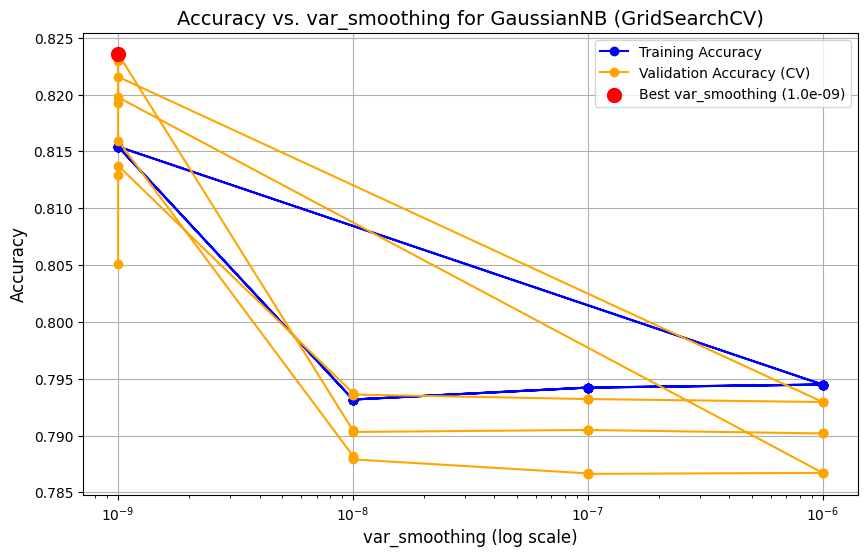

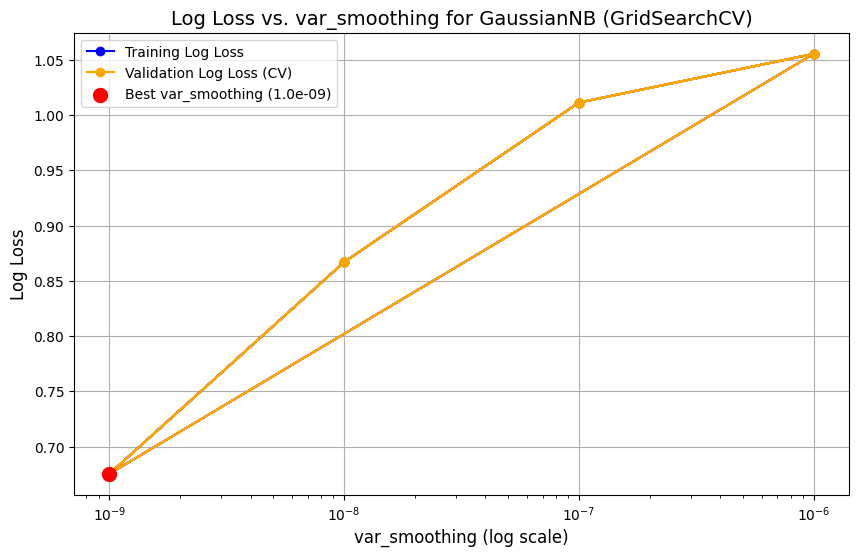

In [ ]:
# Plot Accuracy
plt.figure(figsize=(10, 6))
plt.plot(var_smoothing_values, train_accuracies, label='Training Accuracy', color='blue', marker='o')
plt.plot(var_smoothing_values, val_accuracies, label='Validation Accuracy (CV)', color='orange', marker='o')
plt.scatter([grid_search.best_params_['gaussiannb__var_smoothing']], [grid_search.best_score_],
            color='red', s=100, label=f'Best var_smoothing ({grid_search.best_params_["gaussiannb__var_smoothing"]:.1e})', zorder=5)
plt.xscale('log')
plt.title('Accuracy vs. var_smoothing for GaussianNB (GridSearchCV)', fontsize=14)
plt.xlabel('var_smoothing (log scale)', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend()
plt.grid(True)
plt.show()

# Plot Log Loss
plt.figure(figsize=(10, 6))
plt.plot(var_smoothing_values, train_losses, label='Training Log Loss', color='blue', marker='o')
plt.plot(var_smoothing_values, val_losses, label='Validation Log Loss (CV)', color='orange', marker='o')
plt.scatter([grid_search.best_params_['gaussiannb__var_smoothing']], [min(val_losses)],
            color='red', s=100, label=f'Best var_smoothing ({grid_search.best_params_["gaussiannb__var_smoothing"]:.1e})', zorder=5)
plt.xscale('log')
plt.title('Log Loss vs. var_smoothing for GaussianNB (GridSearchCV)', fontsize=14)
plt.xlabel('var_smoothing (log scale)', fontsize=12)
plt.ylabel('Log Loss', fontsize=12)
plt.legend()
plt.grid(True)
plt.show()

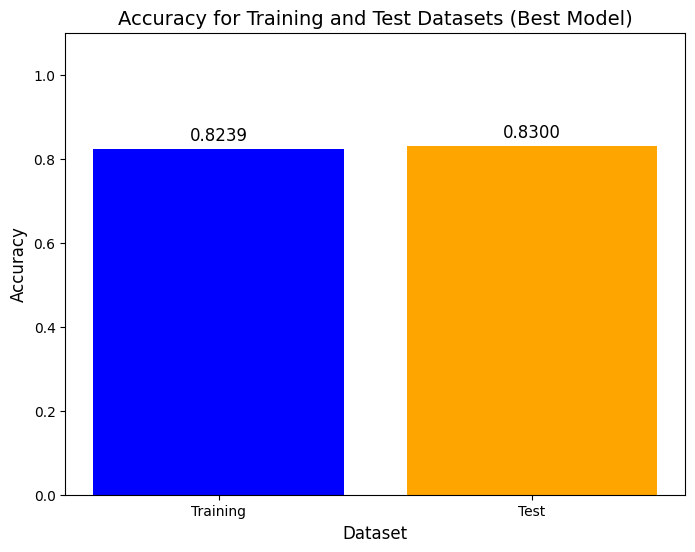

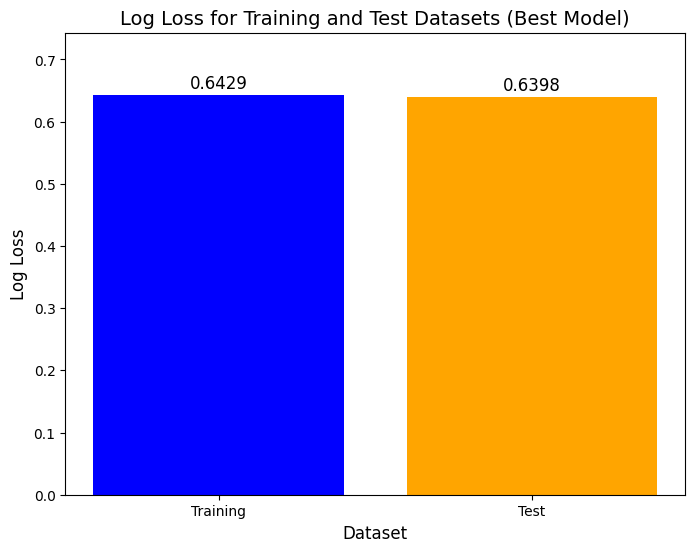

In [ ]:
# Compute training metrics for the best model
y_train_pred = best_model.predict(X_train)
y_train_pred_proba = best_model.predict_proba(X_train)
train_accuracy = accuracy_score(y_train, y_train_pred)
train_loss = log_loss(y_train, y_train_pred_proba)

# Plot Accuracy (Training vs. Test)
plt.figure(figsize=(8, 6))
plt.bar(['Training', 'Test'], [train_accuracy, test_accuracy], color=['blue', 'orange'])
plt.title('Accuracy for Training and Test Datasets (Best Model)', fontsize=14)
plt.ylabel('Accuracy', fontsize=12)
plt.xlabel('Dataset', fontsize=12)
plt.ylim(0, 1.1)
for i, v in enumerate([train_accuracy, test_accuracy]):
    plt.text(i, v + 0.02, f'{v:.4f}', ha='center', fontsize=12)
plt.show()

# Plot Log Loss (Training vs. Test)
plt.figure(figsize=(8, 6))
plt.bar(['Training', 'Test'], [train_loss, test_loss], color=['blue', 'orange'])
plt.title('Log Loss for Training and Test Datasets (Best Model)', fontsize=14)
plt.ylabel('Log Loss', fontsize=12)
plt.xlabel('Dataset', fontsize=12)
plt.ylim(0, max(train_loss, test_loss) + 0.1)
for i, v in enumerate([train_loss, test_loss]):
    plt.text(i, v + 0.01, f'{v:.4f}', ha='center', fontsize=12)
plt.show()

In [74]:
# Define training sizes (e.g., 25%, 50%, 75%, 100% of the training data)
from sklearn.model_selection import GridSearchCV, learning_curve
from sklearn.metrics import log_loss, accuracy_score
train_sizes = np.linspace(0.1, 1.0, 10)  # From 10% to 100% of the training data

# Compute learning curve for accuracy
train_sizes_abs, train_scores_accuracy, val_scores_accuracy = learning_curve(
    best_model,
    X_train,
    y_train,
    train_sizes=train_sizes,
    cv=3,  # 3-fold cross-validation
    scoring='accuracy',
    n_jobs=-1
)

# Compute mean and standard deviation for accuracy
train_mean_accuracy = np.mean(train_scores_accuracy, axis=1)
train_std_accuracy = np.std(train_scores_accuracy, axis=1)
val_mean_accuracy = np.mean(val_scores_accuracy, axis=1)
val_std_accuracy = np.std(val_scores_accuracy, axis=1)

# Compute learning curve for log loss (manually)
train_losses = []
val_losses = []
for train_size in train_sizes_abs:
    # Select a subset of the training data
    subset_size = int(train_size)
    X_subset = X_train.iloc[:subset_size]
    y_subset = y_train.iloc[:subset_size]

    # Fit the model on the subset
    best_model.fit(X_subset, y_subset)

    # Compute training log loss
    y_train_pred_proba = best_model.predict_proba(X_subset)
    train_loss = log_loss(y_subset, y_train_pred_proba)
    train_losses.append(train_loss)

    # Compute validation log loss (approximation using the full training set)
    y_val_pred_proba = best_model.predict_proba(X_train)
    val_loss = log_loss(y_train, y_val_pred_proba)
    val_losses.append(val_loss)

ValueError: y_true contains only one label (0). Please provide the true labels explicitly through the labels argument.

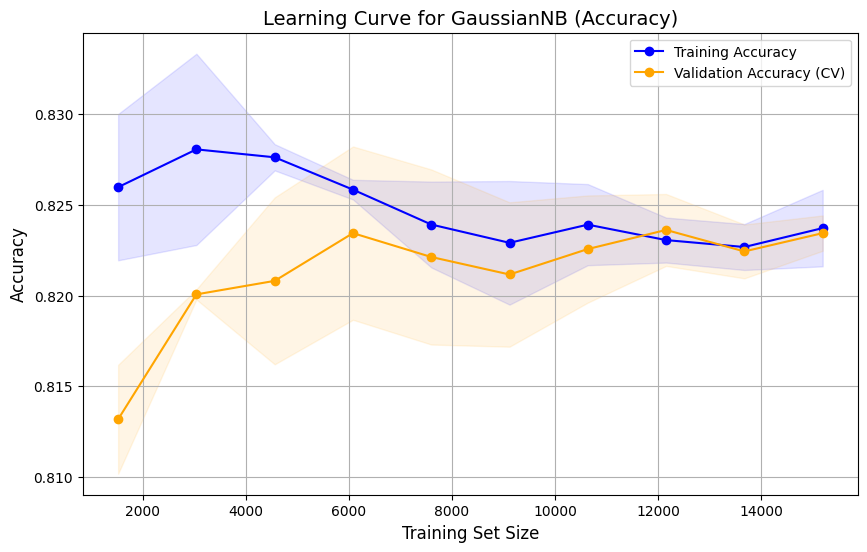

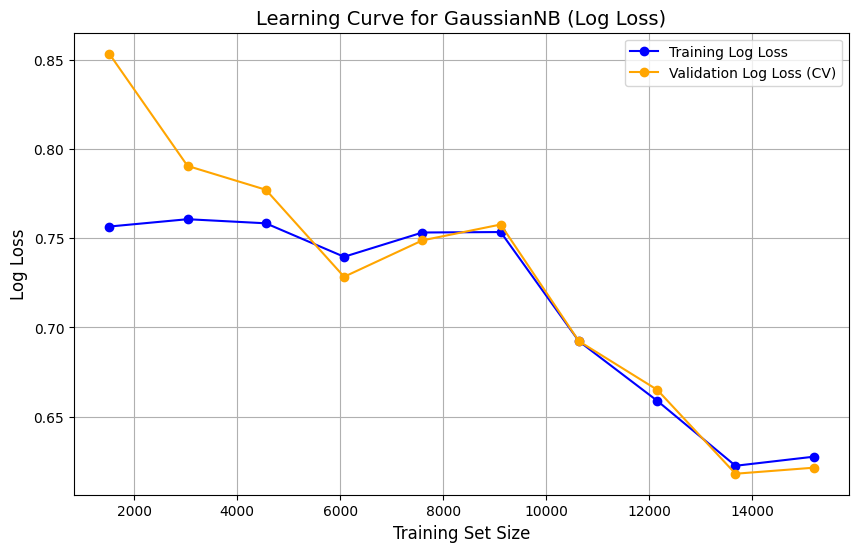

In [ ]:
# Plot Learning Curve for Accuracy
plt.figure(figsize=(10, 6))
plt.plot(train_sizes_abs, train_mean_accuracy, label='Training Accuracy', color='blue', marker='o')
plt.fill_between(train_sizes_abs, train_mean_accuracy - train_std_accuracy, train_mean_accuracy + train_std_accuracy,
                 color='blue', alpha=0.1)
plt.plot(train_sizes_abs, val_mean_accuracy, label='Validation Accuracy (CV)', color='orange', marker='o')
plt.fill_between(train_sizes_abs, val_mean_accuracy - val_std_accuracy, val_mean_accuracy + val_std_accuracy,
                 color='orange', alpha=0.1)
plt.title('Learning Curve for GaussianNB (Accuracy)', fontsize=14)
plt.xlabel('Training Set Size', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend()
plt.grid(True)
plt.show()

# Plot Learning Curve for Log Loss
plt.figure(figsize=(10, 6))
plt.plot(train_sizes_abs, train_losses, label='Training Log Loss', color='blue', marker='o')
plt.plot(train_sizes_abs, val_losses, label='Validation Log Loss (CV)', color='orange', marker='o')
plt.title('Learning Curve for GaussianNB (Log Loss)', fontsize=14)
plt.xlabel('Training Set Size', fontsize=12)
plt.ylabel('Log Loss', fontsize=12)
plt.legend()
plt.grid(True)
plt.show()

In [75]:
# Compute metrics on the training set
y_train_pred = best_model.predict(X_train)
y_train_pred_proba = best_model.predict_proba(X_train)
train_accuracy = accuracy_score(y_train, y_train_pred)
train_loss = log_loss(y_train, y_train_pred_proba)

# Compute metrics on the test set
y_test_pred = best_model.predict(X_test)
y_test_pred_proba = best_model.predict_proba(X_test)
test_accuracy = accuracy_score(y_test, y_test_pred)
test_loss = log_loss(y_test, y_test_pred_proba)

print(f"Training Accuracy (Best Model): {train_accuracy:.4f}")
print(f"Test Accuracy (Best Model): {test_accuracy:.4f}")
print(f"Training Log Loss (Best Model): {train_loss:.4f}")
print(f"Test Log Loss (Best Model): {test_loss:.4f}")

# Plot Accuracy (Training vs. Test)
plt.figure(figsize=(8, 6))
plt.bar(['Training', 'Test'], [train_accuracy, test_accuracy], color=['blue', 'orange'])
plt.title('Accuracy for Training and Test Datasets (Best Model)', fontsize=14)
plt.ylabel('Accuracy', fontsize=12)
plt.xlabel('Dataset', fontsize=12)
plt.ylim(0, 1.1)
for i, v in enumerate([train_accuracy, test_accuracy]):
    plt.text(i, v + 0.02, f'{v:.4f}', ha='center', fontsize=12)
plt.show()

# Plot Log Loss (Training vs. Test)
plt.figure(figsize=(8, 6))
plt.bar(['Training', 'Test'], [train_loss, test_loss], color=['blue', 'orange'])
plt.title('Log Loss for Training and Test Datasets (Best Model)', fontsize=14)
plt.ylabel('Log Loss', fontsize=12)
plt.xlabel('Dataset', fontsize=12)
plt.ylim(0, max(train_loss, test_loss) + 0.1)
for i, v in enumerate([train_loss, test_loss]):
    plt.text(i, v + 0.01, f'{v:.4f}', ha='center', fontsize=12)
plt.show()

ValueError: y_true contains only one label (0). Please provide the true labels explicitly through the labels argument.

In [ ]:

# Predict on the test data using the best model
y_pred = grid_search.predict(X_test)
print("Predictions on X_test:", y_pred)

Predictions on X_test: [' <=50K' ' <=50K' ' <=50K' ... ' >50K' ' <=50K' ' <=50K']


In [ ]:
# Extract training and validation losses from cv_results_
train_losses = -grid_search_result.cv_results_['mean_train_score']  # Convert to positive log loss
val_losses = -grid_search_result.cv_results_['mean_test_score']  # Convert to positive log loss

# Extract the parameter combinations for the x-axis
param_combinations = [
    f"priors={priors}, var_smoothing={var_smoothing:.1e}"
    for priors, var_smoothing in zip(
        grid_search_result.cv_results_['param_gaussiannb__priors'],
        grid_search_result.cv_results_['param_gaussiannb__var_smoothing']
    )
]

KeyError: 'mean_train_score'

In [ ]:
X_test.shape

(9769, 14)

We now have training and testing set ready for model building. Before that, we should map all the feature variables onto the same scale. It is called `feature scaling`. I will do it as follows.

# **11. Feature Scaling** <a class="anchor" id="11"></a>

[Table of Contents](#0.1)

In [ ]:
cols = X_train.columns

In [ ]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)


In [ ]:
X_train = pd.DataFrame(X_train, columns=[cols])

In [ ]:
X_test = pd.DataFrame(X_test, columns=[cols])

In [ ]:
X_train.head()

We now have `X_train` dataset ready to be fed into the Gaussian Naive Bayes classifier. I will do it as follows.

# **12. Model training** <a class="anchor" id="12"></a>

[Table of Contents](#0.1)

In [ ]:
# train a Gaussian Naive Bayes classifier on the training set
from sklearn.naive_bayes import GaussianNB


# instantiate the model
gnb = GaussianNB()


# fit the model
gnb.fit(X_train, y_train)


# **13. Predict the results** <a class="anchor" id="13"></a>

[Table of Contents](#0.1)

In [ ]:
y_pred = gnb.predict(X_test)

y_pred

# **14. Check accuracy score** <a class="anchor" id="14"></a>

[Table of Contents](#0.1)

In [ ]:
from sklearn.metrics import accuracy_score

print('Model accuracy score: {0:0.4f}'. format(accuracy_score(y_test, y_pred)))

Here, **y_test** are the true class labels and **y_pred** are the predicted class labels in the test-set.

### Compare the train-set and test-set accuracy


Now, I will compare the train-set and test-set accuracy to check for overfitting.

In [ ]:
y_pred_train = gnb.predict(X_train)

y_pred_train

In [ ]:
print('Training-set accuracy score: {0:0.4f}'. format(accuracy_score(y_train, y_pred_train)))

### Check for overfitting and underfitting

In [ ]:
# print the scores on training and test set

print('Training set score: {:.4f}'.format(gnb.score(X_train, y_train)))

print('Test set score: {:.4f}'.format(gnb.score(X_test, y_test)))

The training-set accuracy score is 0.8067 while the test-set accuracy to be 0.8083. These two values are quite comparable. So, there is no sign of overfitting.


### Compare model accuracy with null accuracy


So, the model accuracy is 0.8083. But, we cannot say that our model is very good based on the above accuracy. We must compare it with the **null accuracy**. Null accuracy is the accuracy that could be achieved by always predicting the most frequent class.

So, we should first check the class distribution in the test set.

In [ ]:
# check class distribution in test set

y_test.value_counts()

We can see that the occurences of most frequent class is 7407. So, we can calculate null accuracy by dividing 7407 by total number of occurences.

In [ ]:
# check null accuracy score

null_accuracy = (7407/(7407+2362))

print('Null accuracy score: {0:0.4f}'. format(null_accuracy))

We can see that our model accuracy score is 0.8083 but null accuracy score is 0.7582. So, we can conclude that our Gaussian Naive Bayes Classification model is doing a very good job in predicting the class labels.

Now, based on the above analysis we can conclude that our classification model accuracy is very good. Our model is doing a very good job in terms of predicting the class labels.


But, it does not give the underlying distribution of values. Also, it does not tell anything about the type of errors our classifer is making.


We have another tool called `Confusion matrix` that comes to our rescue.

# **15. Confusion matrix** <a class="anchor" id="15"></a>

[Table of Contents](#0.1)


A confusion matrix is a tool for summarizing the performance of a classification algorithm. A confusion matrix will give us a clear picture of classification model performance and the types of errors produced by the model. It gives us a summary of correct and incorrect predictions broken down by each category. The summary is represented in a tabular form.


Four types of outcomes are possible while evaluating a classification model performance. These four outcomes are described below:-


**True Positives (TP)** – True Positives occur when we predict an observation belongs to a certain class and the observation actually belongs to that class.


**True Negatives (TN)** – True Negatives occur when we predict an observation does not belong to a certain class and the observation actually does not belong to that class.


**False Positives (FP)** – False Positives occur when we predict an observation belongs to a    certain class but the observation actually does not belong to that class. This type of error is called **Type I error.**



**False Negatives (FN)** – False Negatives occur when we predict an observation does not belong to a certain class but the observation actually belongs to that class. This is a very serious error and it is called **Type II error.**



These four outcomes are summarized in a confusion matrix given below.


In [ ]:
# Print the Confusion Matrix and slice it into four pieces

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print('Confusion matrix\n\n', cm)

print('\nTrue Positives(TP) = ', cm[0,0])

print('\nTrue Negatives(TN) = ', cm[1,1])

print('\nFalse Positives(FP) = ', cm[0,1])

print('\nFalse Negatives(FN) = ', cm[1,0])

The confusion matrix shows `5999 + 1897 = 7896 correct predictions` and `1408 + 465 = 1873 incorrect predictions`.


In this case, we have


- `True Positives` (Actual Positive:1 and Predict Positive:1) - 5999


- `True Negatives` (Actual Negative:0 and Predict Negative:0) - 1897


- `False Positives` (Actual Negative:0 but Predict Positive:1) - 1408 `(Type I error)`


- `False Negatives` (Actual Positive:1 but Predict Negative:0) - 465 `(Type II error)`

In [ ]:
# visualize confusion matrix with seaborn heatmap

cm_matrix = pd.DataFrame(data=cm, columns=['Actual Positive:1', 'Actual Negative:0'],
                                 index=['Predict Positive:1', 'Predict Negative:0'])

sns.heatmap(cm_matrix, annot=True, fmt='d', cmap='YlGnBu')

# **16. Classification metrices** <a class="anchor" id="16"></a>

[Table of Contents](#0.1)

### Classification Report


**Classification report** is another way to evaluate the classification model performance. It displays the  **precision**, **recall**, **f1** and **support** scores for the model. I have described these terms in later.

We can print a classification report as follows:-

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

### Classification accuracy

In [ ]:
TP = cm[0,0]
TN = cm[1,1]
FP = cm[0,1]
FN = cm[1,0]

In [ ]:
# print classification accuracy

classification_accuracy = (TP + TN) / float(TP + TN + FP + FN)

print('Classification accuracy : {0:0.4f}'.format(classification_accuracy))


### Classification error

In [ ]:
# print classification error

classification_error = (FP + FN) / float(TP + TN + FP + FN)

print('Classification error : {0:0.4f}'.format(classification_error))


### Precision


**Precision** can be defined as the percentage of correctly predicted positive outcomes out of all the predicted positive outcomes. It can be given as the ratio of true positives (TP) to the sum of true and false positives (TP + FP).


So, **Precision** identifies the proportion of correctly predicted positive outcome. It is more concerned with the positive class than the negative class.



Mathematically, precision can be defined as the ratio of `TP to (TP + FP)`.



In [ ]:
# print precision score

precision = TP / float(TP + FP)


print('Precision : {0:0.4f}'.format(precision))


### Recall


Recall can be defined as the percentage of correctly predicted positive outcomes out of all the actual positive outcomes.
It can be given as the ratio of true positives (TP) to the sum of true positives and false negatives (TP + FN). **Recall** is also called **Sensitivity**.


**Recall** identifies the proportion of correctly predicted actual positives.


Mathematically, recall can be given as the ratio of `TP to (TP + FN)`.



In [ ]:
recall = TP / float(TP + FN)

print('Recall or Sensitivity : {0:0.4f}'.format(recall))

### True Positive Rate


**True Positive Rate** is synonymous with **Recall**.


In [ ]:
true_positive_rate = TP / float(TP + FN)


print('True Positive Rate : {0:0.4f}'.format(true_positive_rate))

### False Positive Rate

In [ ]:
false_positive_rate = FP / float(FP + TN)


print('False Positive Rate : {0:0.4f}'.format(false_positive_rate))

### Specificity

In [ ]:
specificity = TN / (TN + FP)

print('Specificity : {0:0.4f}'.format(specificity))

### f1-score


**f1-score** is the weighted harmonic mean of precision and recall. The best possible **f1-score** would be 1.0 and the worst
would be 0.0.  **f1-score** is the harmonic mean of precision and recall. So, **f1-score** is always lower than accuracy measures as they embed precision and recall into their computation. The weighted average of `f1-score` should be used to
compare classifier models, not global accuracy.




### Support


**Support** is the actual number of occurrences of the class in our dataset.

# **17. Calculate class probabilities** <a class="anchor" id="17"></a>

[Table of Contents](#0.1)

In [ ]:
# print the first 10 predicted probabilities of two classes- 0 and 1

y_pred_prob = gnb.predict_proba(X_test)[0:10]

y_pred_prob

### Observations


- In each row, the numbers sum to 1.


- There are 2 columns which correspond to 2 classes - `<=50K` and `>50K`.

    - Class 0 => <=50K - Class that a person makes less than equal to 50K.    
    
    - Class 1 => >50K  - Class that a person makes more than 50K.
        
    
- Importance of predicted probabilities

    - We can rank the observations by probability of whether a person makes less than or equal to 50K or more than 50K.


- predict_proba process

    - Predicts the probabilities    
    
    - Choose the class with the highest probability    
    
    
- Classification threshold level

    - There is a classification threshold level of 0.5.    
    
    - Class 0 => <=50K - probability of salary less than or equal to 50K is predicted if probability < 0.5.    
    
    - Class 1 => >50K - probability of salary more than 50K is predicted if probability > 0.5.    
    


In [ ]:
# store the probabilities in dataframe

y_pred_prob_df = pd.DataFrame(data=y_pred_prob, columns=['Prob of - <=50K', 'Prob of - >50K'])

y_pred_prob_df

In [ ]:
# print the first 10 predicted probabilities for class 1 - Probability of >50K

gnb.predict_proba(X_test)[0:10, 1]

In [ ]:
# store the predicted probabilities for class 1 - Probability of >50K

y_pred1 = gnb.predict_proba(X_test)[:, 1]

In [ ]:
# plot histogram of predicted probabilities


# adjust the font size
plt.rcParams['font.size'] = 12


# plot histogram with 10 bins
plt.hist(y_pred1, bins = 10)


# set the title of predicted probabilities
plt.title('Histogram of predicted probabilities of salaries >50K')


# set the x-axis limit
plt.xlim(0,1)


# set the title
plt.xlabel('Predicted probabilities of salaries >50K')
plt.ylabel('Frequency')

### Observations


- We can see that the above histogram is highly positive skewed.


- The first column tell us that there are approximately 5700 observations with probability between 0.0 and 0.1 whose salary
  is <=50K.


- There are relatively small number of observations with probability > 0.5.


- So, these small number of observations predict that the salaries will be >50K.


- Majority of observations predcit that the salaries will be <=50K.

# **18. ROC - AUC** <a class="anchor" id="18"></a>

[Table of Contents](#0.1)



### ROC Curve


Another tool to measure the classification model performance visually is **ROC Curve**. ROC Curve stands for **Receiver Operating Characteristic Curve**. An **ROC Curve** is a plot which shows the performance of a classification model at various
classification threshold levels.



The **ROC Curve** plots the **True Positive Rate (TPR)** against the **False Positive Rate (FPR)** at various threshold levels.



**True Positive Rate (TPR)** is also called **Recall**. It is defined as the ratio of `TP to (TP + FN)`.




**False Positive Rate (FPR)** is defined as the ratio of `FP to (FP + TN)`.



In the ROC Curve, we will focus on the TPR (True Positive Rate) and FPR (False Positive Rate) of a single point. This will give us the general performance of the ROC curve which consists of the TPR and FPR at various threshold levels. So, an ROC Curve plots TPR vs FPR at different classification threshold levels. If we lower the threshold levels, it may result in more items being classified as positve. It will increase both True Positives (TP) and False Positives (FP).



In [ ]:
# plot ROC Curve

from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_pred1, pos_label = '>50K')

plt.figure(figsize=(6,4))

plt.plot(fpr, tpr, linewidth=2)

plt.plot([0,1], [0,1], 'k--' )

plt.rcParams['font.size'] = 12

plt.title('ROC curve for Gaussian Naive Bayes Classifier for Predicting Salaries')

plt.xlabel('False Positive Rate (1 - Specificity)')

plt.ylabel('True Positive Rate (Sensitivity)')

plt.show()


ROC curve help us to choose a threshold level that balances sensitivity and specificity for a particular context.

### ROC  AUC


**ROC AUC** stands for **Receiver Operating Characteristic - Area Under Curve**. It is a technique to compare classifier performance. In this technique, we measure the `area under the curve (AUC)`. A perfect classifier will have a ROC AUC equal to 1, whereas a purely random classifier will have a ROC AUC equal to 0.5.


So, **ROC AUC** is the percentage of the ROC plot that is underneath the curve.

In [ ]:
# compute ROC AUC

from sklearn.metrics import roc_auc_score

ROC_AUC = roc_auc_score(y_test, y_pred1)

print('ROC AUC : {:.4f}'.format(ROC_AUC))

### Interpretation


- ROC AUC is a single number summary of classifier performance. The higher the value, the better the classifier.

- ROC AUC of our model approaches towards 1. So, we can conclude that our classifier does a good job in predicting whether it will rain tomorrow or not.

In [ ]:
# calculate cross-validated ROC AUC

from sklearn.model_selection import cross_val_score

Cross_validated_ROC_AUC = cross_val_score(gnb, X_train, y_train, cv=5, scoring='roc_auc').mean()

print('Cross validated ROC AUC : {:.4f}'.format(Cross_validated_ROC_AUC))

# **19. k-Fold Cross Validation** <a class="anchor" id="19"></a>

[Table of Contents](#0.1)

In [ ]:
# Applying 10-Fold Cross Validation

from sklearn.model_selection import cross_val_score

scores = cross_val_score(gnb, X_train, y_train, cv = 10, scoring='accuracy')

print('Cross-validation scores:{}'.format(scores))

We can summarize the cross-validation accuracy by calculating its mean.

In [ ]:
# compute Average cross-validation score

print('Average cross-validation score: {:.4f}'.format(scores.mean()))

### Interpretation


- Using the mean cross-validation, we can conclude that we expect the model to be around 80.63% accurate on average.

- If we look at all the 10 scores produced by the 10-fold cross-validation, we can also conclude that there is a relatively small variance in the accuracy between folds, ranging from 81.35% accuracy to 79.64% accuracy. So, we can conclude that the model is independent of the particular folds used for training.

- Our original model accuracy is 0.8083, but the mean cross-validation accuracy is 0.8063. So, the 10-fold cross-validation accuracy does not result in performance improvement for this model.

# **20. Results and conclusion** <a class="anchor" id="20"></a>

[Table of Contents](#0.1)


1.	In this project, I build a Gaussian Naïve Bayes Classifier model to predict whether a person makes over 50K a year. The model yields a very good performance as indicated by the model accuracy which was found to be 0.8083.
2.	The training-set accuracy score is 0.8067 while the test-set accuracy to be 0.8083. These two values are quite comparable. So, there is no sign of overfitting.
3.	I have compared the model accuracy score which is 0.8083 with null accuracy score which is 0.7582. So, we can conclude that our Gaussian Naïve Bayes classifier model is doing a very good job in predicting the class labels.
4.	ROC AUC of our model approaches towards 1. So, we can conclude that our classifier does a very good job in predicting whether a person makes over 50K a year.
5.	Using the mean cross-validation, we can conclude that we expect the model to be around 80.63% accurate on average.
6.	If we look at all the 10 scores produced by the 10-fold cross-validation, we can also conclude that there is a relatively small variance in the accuracy between folds, ranging from 81.35% accuracy to 79.64% accuracy. So, we can conclude that the model is independent of the particular folds used for training.
7.	Our original model accuracy is 0.8083, but the mean cross-validation accuracy is 0.8063. So, the 10-fold cross-validation accuracy does not result in performance improvement for this model.

# **21. References** <a class="anchor" id="21"></a>

[Table of Contents](#0.1)



The work done in this project is inspired from following books and websites:-

1. Hands on Machine Learning with Scikit-Learn and Tensorflow by Aurélién Géron

2. Introduction to Machine Learning with Python by Andreas C. Müller and Sarah Guido

3. Udemy course – Machine Learning – A Z by Kirill Eremenko and Hadelin de Ponteves

4. https://en.wikipedia.org/wiki/Naive_Bayes_classifier

5. http://dataaspirant.com/2017/02/06/naive-bayes-classifier-machine-learning/

6. https://www.datacamp.com/community/tutorials/naive-bayes-scikit-learn

7. https://stackabuse.com/the-naive-bayes-algorithm-in-python-with-scikit-learn/

8. https://jakevdp.github.io/PythonDataScienceHandbook/05.05-naive-bayes.html

So, now we will come to the end of this kernel.

I hope you find this kernel useful and enjoyable.

Your comments and feedback are most welcome.

Thank you


[Go to Top](#0)